# Option Pricing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
import pandas as pd
import seaborn as sns

from utilsAsian import *

# Parameters for the Heston model
S0 = 100
K = 110
M = 15000
V0 = 0.04
T = 1
theta = 0.04
r = 0.05
rho = -0.5
kappa = 1.5
dt = 0.001
xi = 0.25

seed = 42

In [3]:
dts = np.logspace(-4, -1, 15)

e_mean  = np.zeros_like(dts)  
e_half  = np.zeros_like(dts) 
m_mean  = np.zeros_like(dts)   
m_half  = np.zeros_like(dts)   

# Euler vs Milstein. We increment the seed for each dt to get different random numbers so the MC errors reflect true independent noise
for i, dt in enumerate(dts):
    (pe, loE, hiE), (pm, loM, hiM) = heston_mc(M, S0, V0, K, T, dt, r, rho, kappa, theta, xi,seed+i)
    e_mean[i] = pe
    e_half[i] = 0.5 * (hiE - loE)
    m_mean[i] = pm
    m_half[i] = 0.5 * (hiM - loM)

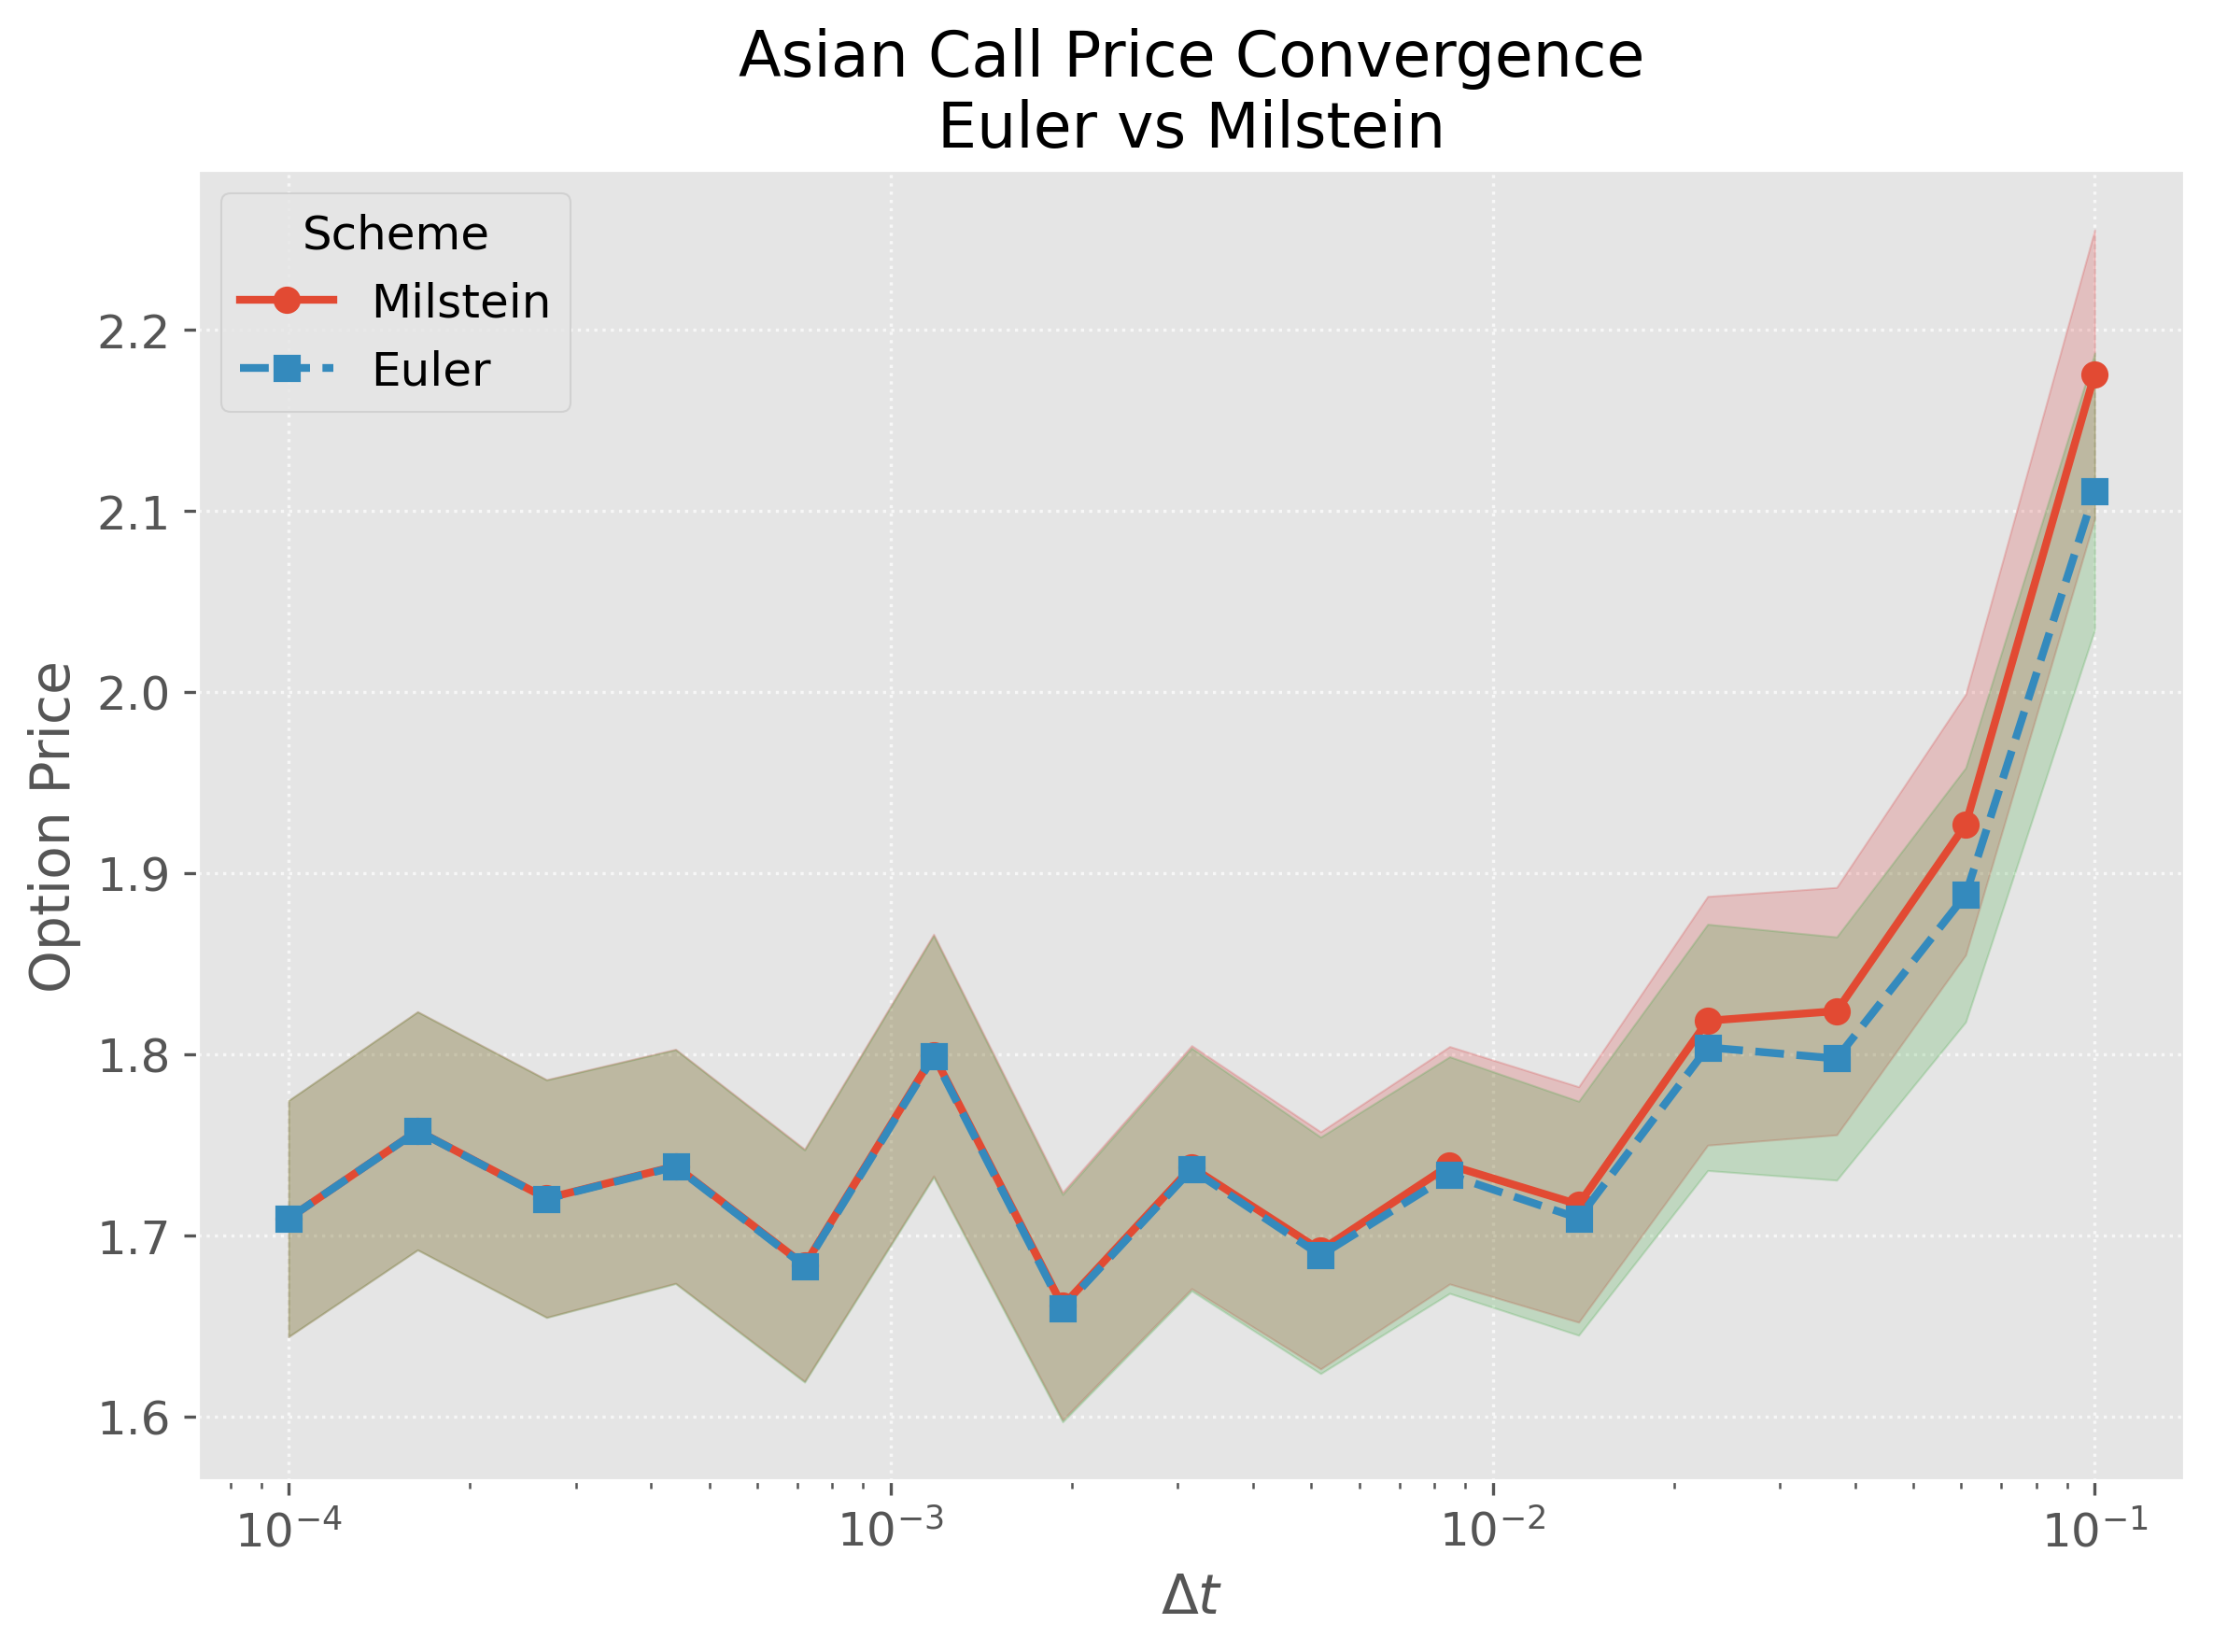

In [4]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Milstein: line + shaded CI
ax.plot(dts, m_mean,
        marker='o', linestyle='-',
        linewidth=2, markersize=6,
        label='Milstein')
ax.fill_between(dts, m_mean - m_half, m_mean + m_half,
                color='#d62728', alpha=0.2)

# Euler call price 
ax.plot(dts, e_mean,
        marker='s', linestyle='--',
        linewidth=2, markersize=6,
        label='Euler')
ax.fill_between(dts, e_mean - e_half, e_mean + e_half,
                color='#2ca02c', alpha=0.2)

ax.set_xscale('log')
ax.set_xlabel(r'$\Delta t$', fontsize=14)
ax.set_ylabel('Option Price', fontsize=14)
ax.set_title('Asian Call Price Convergence\nEuler vs Milstein', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(title='Scheme', frameon=True, fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# sanity ξ = 0 check: Heston → GBM with σ = √V0
V0     = 0.04
xi     = 0.0
vol_gbm = np.sqrt(V0)     


(pe, lo_e, hi_e), (pm, lo_m, hi_m) = heston_mc(
    M, S0, V0, K, T, dt, r, rho, kappa, theta, xi, seed
)

gbm_price, gbm_halfCI = gbm(
    paths  = M,
    s0     = S0,
    strike = K,
    expiry = T,
    rate   = r,
    vol    = vol_gbm,    
    dt     = dt,
    seed   = seed
)
print(f"Euler     : {pe:.6f} ± {(hi_e-lo_e)/2:.6f}")
print(f"Milstein  : {pm:.6f} ± {(hi_m-lo_m)/2:.6f}")
print(f"GBM bench : {gbm_price:.6f} ± {gbm_halfCI:.6f}")

Euler     : 2.382896 ± 0.088942
Milstein  : 2.436608 ± 0.092082
GBM bench : 2.350893 ± 0.087898


In [6]:
N = int(T / dt)
sigma = 0.3

analytic_geo_price = geometric_analytical_asian(S0, K, r, sigma, T, N)
print(f"Analytical geometric Asian call price: {analytic_geo_price:.6f}")

# Test case: Zero volatility case (sigma = 0)
S0, K, r, T, N = 100, 110, 0.05, 1.0, 100
analytic_zero = geometric_analytical_asian(S0, K, r, 0.0, T, N)
expected_zero = S0 - K * np.exp(-r * T)
print(f"Sigma=0 analytic: {analytic_zero:.6f}, Expected: {expected_zero:.6f}")

# Test case: Zero interest rate case (r = 0)
paths = 200_000
sigma_test = 0.3
mc_price, mc_ci = mc_geometric_asian(paths, S0, K, r, sigma_test, T, N, 42)
analytic_price = geometric_analytical_asian(S0, K, r, sigma_test, T, N)
print(f"MC geometric price: {mc_price:.6f} ± {mc_ci:.6f} (95% CI)")
print(f"Analytic geometric price: {analytic_price:.6f}")


Analytical geometric Asian call price: 3.555070
Sigma=0 analytic: 0.000000, Expected: -4.635237
MC geometric price: 3.693282 ± 0.036059 (95% CI)
Analytic geometric price: 3.703944


In [ ]:
# run control variate MC
params = {
    "M": 15000, "S0": 100, "V0": 0.04, "K": 110, "T": 1.0, "dt": 0.001,
    "r": 0.05, "rho": -0.5, "kappa": 1.5, "theta": 0.04, "xi": 0.25, 
    "sigma": 0.3,  "c" : 1.0, "seed": 42
}
results = control_variate_MC(**params)
plain_price, plain_se, plain_var       = results["plain"]
cv_price,    cv_se,    cv_var          = results["control_var"]
analytic_geo_price                  = results["analy_price"]

print(f"Analytic geometric price (target): {analytic_geo_price:.6f}")
print(f"Plain MC   : price = {plain_price:.6f}, SE = {plain_se:.6f}, var = {plain_var:.6e}")
print(f"CV (c=1)   : price = {cv_price:.6f}, SE = {cv_se:.6f}, var = {cv_var:.6e}")

# empirically optimal c:
Y, X = results["payoffs"]
cov_YX = np.cov(Y, X, ddof=1)[0,1]
var_X  = X.var(ddof=1)
c_opt  = -cov_YX/var_X
print(f"Empirical optimal c*: {c_opt:.4f}")


Analytic geometric price (target): 3.720210
Plain MC   : price = 1.744516, SE = 0.033023, var = 1.635801e+01
CV (c=1)   : price = 1.723280, SE = 0.038719, var = 2.248697e+01
Empirical optimal c*: -0.4541


,M,plain_se,cv_se,SE_reduction
0,1000,0.124488,0.151630,0.821001
1,2000,0.098159,0.109802,0.893962
2,5000,0.058263,0.066265,0.879246
3,10000,0.042117,0.048282,0.872309
4,25000,0.025678,0.030606,0.838991
5,100000,0.012904,0.015107,0.854218


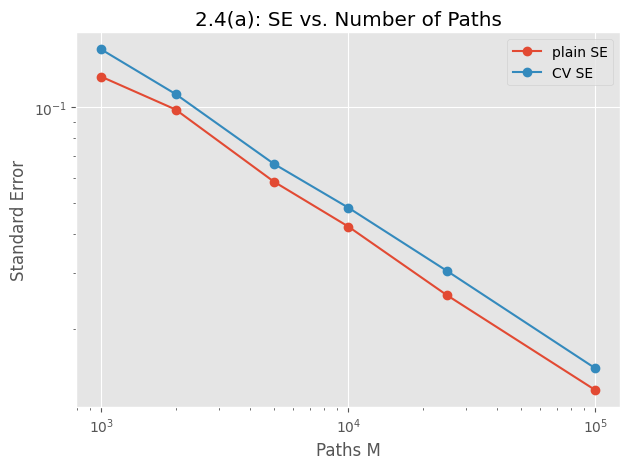

In [11]:
Ms = [1000, 2000, 5000, 10000, 25000, 100000]
results_a = []
for M in Ms:
    currentparms = params.copy()
    currentparms.update({"M": M, "K": 110, "rho": -0.5, "xi": 0.25, "sigma": 0.3, "c": 1.0})
    out = control_variate_MC(**currentparms)
    p, p_se, _ = out["plain"]
    cv, cv_se, _ = out["control_var"]
    results_a.append({"M": M, "plain_se": p_se, "cv_se": cv_se, "SE_reduction": p_se/cv_se})

df_a = pd.DataFrame(results_a)
display(df_a)

plt.figure()
plt.plot(df_a["M"], df_a["plain_se"], marker="o", label="plain SE")
plt.plot(df_a["M"], df_a["cv_se"],    marker="o", label="CV SE")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Paths M"); plt.ylabel("Standard Error")
plt.title("2.4(a): SE vs. Number of Paths")
plt.legend(); plt.tight_layout(); plt.show()


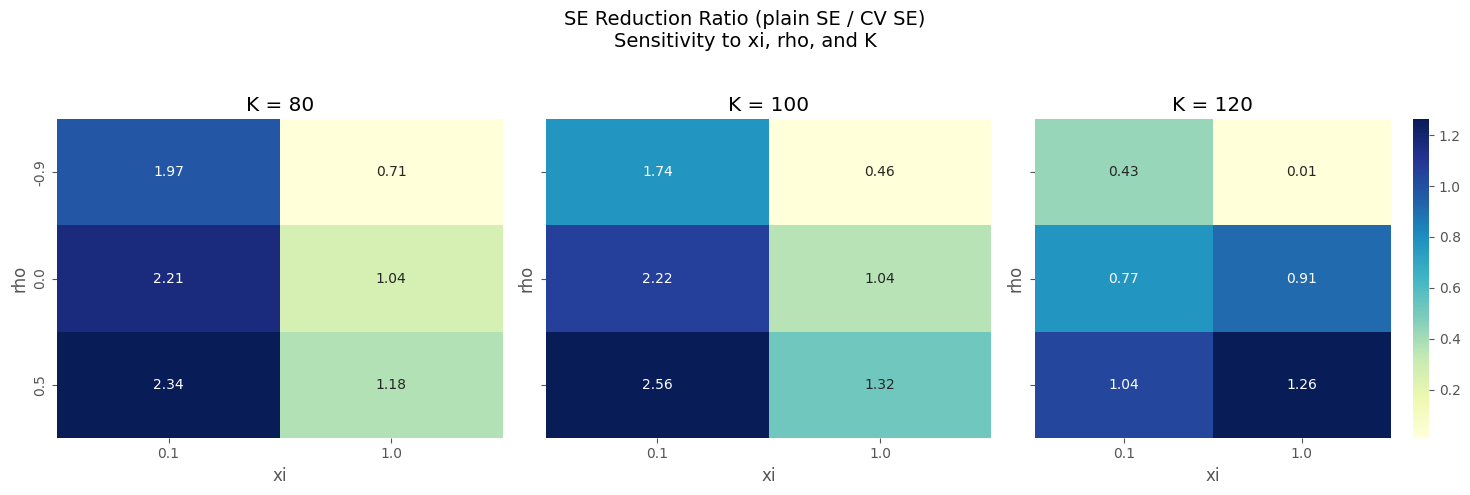

In [17]:
# sensitivity analysis: xi, rho, K
xis  = [0.1, 1.0]
rhos = [-0.9, 0.0, 0.5]
Ks   = [80, 100, 120]
results_b = []
for xi in xis:
    for rho in rhos:
        for K in Ks:
            curpar = params.copy()
            curpar.update({"M":15000, "K":K, "rho":rho, "xi":xi, "sigma":0.3, "c":1.0})
            out = control_variate_MC(**curpar)
            _, p_se, _ = out["plain"]
            _, cv_se, _ = out["control_var"]
            results_b.append({"xi":xi, "rho":rho, "K":K, "plain_se":p_se, "cv_se":cv_se, "SE_reduction":p_se/cv_se})

df_b = pd.DataFrame(results_b)

fig, axes = plt.subplots(1, len(Ks), figsize=(15, 5), sharey=True)
for i, K in enumerate(Ks):
    df_k = df_b[df_b["K"] == K].pivot(index="rho", columns="xi", values="SE_reduction")
    sns.heatmap(df_k, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[i], cbar=i==len(Ks)-1)
    axes[i].set_title(f"K = {K}")
    axes[i].set_xlabel("xi")
    if i == 0:
        axes[i].set_ylabel("rho")

plt.suptitle("SE Reduction Ratio (plain SE / CV SE)\nSensitivity to xi, rho, and K", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# (c) empirical Optimal c*
# Due to time limitations, we will only compute the empirical optimal c* for a single set of parameters
curpar = params.copy()
curpar.update({"M":15000, "K":110, "rho":-0.5, "xi":0.25, "sigma":0.3, "c":1.0})
Y, X = control_variate_MC(**curpar)["payoffs"]
cov_YX = np.cov(Y, X, ddof=1)[0,1]
var_X  = X.var(ddof=1)
c_opt  = -cov_YX / var_X
print(f"2.4(c): Empirical optimal c* = {c_opt:.4f}")

2.4(c): Empirical optimal c* = -0.4541


Lastly, to gain better performance, we estimate the optimal value for the control variate coefficient.